## UK RAILWAY ANALYSIS

**Author:** MIchael Kodua Boamah 
**Date:** 20th July, 2025

The purpose of this analysis is to explore the operational performance of train journeys, understand the impact and reasons for  delays and cancellations of booked trips and investigate patterns behind refund requests. My goal is to uncover inefficiencies and recommend data-driven strategies to reduce revenue loss and improve passengers experience.

The dataset contains information on individual journeys, including:
- transaction_id       
- date_of_purchase     
- time_of_purchase     
- purchase_type
- payment_method
- railcard
- ticket_class
- ticket_type
- price
- departure_station
- arrival_destination
- date_of_journey
- departure_time
- arrival_time
- actual_arrival_time
- journey_status
- reason_for_delay
- refund_request 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

original_dataset = pd.read_csv(r"C:\Users\MICHAEL KODUA BOAMAH\Desktop\PROJECTS\DATASET\UK TRAIN DATASET\Dataset\railway.csv")

df = original_dataset.copy()

### Data Cleaning and Preparation

I will be inspecting the data set to identify data types, null and other inconsistent values if any to make it appropriate for the analysis. I will be generating new columns: day_of_purchase, day_of_journey, trip_minutes, delay_minutes, route, purchase_hour, day_of_purchase and departure_hour, that would all be essential to acheive the objectives of this analysis and support route-level analysis. I will also be creating binary columns to aid my analysis as well.

Cleaned and formated dates and times columns to extract excaat details also needed for analysis. I also handled missing values using context-specific imputations ("Not Eligible" and "None").

In [2]:
df.shape
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   transaction_id       31653 non-null  object
 1   date_of_purchase     31653 non-null  object
 2   time_of_purchase     31653 non-null  object
 3   purchase_type        31653 non-null  object
 4   payment_method       31653 non-null  object
 5   railcard             10735 non-null  object
 6   ticket_class         31653 non-null  object
 7   ticket_type          31653 non-null  object
 8   price                31653 non-null  int64 
 9   departure_station    31653 non-null  object
 10  arrival_destination  31653 non-null  object
 11  date_of_journey      31653 non-null  object
 12  departure_time       31653 non-null  object
 13  arrival_time         31653 non-null  object
 14  actual_arrival_time  29773 non-null  object
 15  journey_status       31653 non-null  object
 16  reas

,transaction_id,date_of_purchase,time_of_purchase,purchase_type,payment_method,railcard,ticket_class,ticket_type,price,departure_station,arrival_destination,date_of_journey,departure_time,arrival_time,actual_arrival_time,journey_status,reason_for_delay,refund_request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No


In [3]:
df = df.drop(columns="transaction_id")

In [4]:
df.describe(include="all")

,date_of_purchase,time_of_purchase,purchase_type,payment_method,railcard,ticket_class,ticket_type,price,departure_station,arrival_destination,date_of_journey,departure_time,arrival_time,actual_arrival_time,journey_status,reason_for_delay,refund_request
count,31653,31653,31653,31653,10735,31653,31653,31653.000000,31653,31653,31653,31653,31653,29773,31653,4172,31653
unique,128,24351,2,3,3,2,3,NaN,12,32,121,96,203,623,3,8,2
top,2024-02-02,8:16:53,Online,Credit Card,Adult,Standard,Advance,NaN,Manchester Piccadilly,Birmingham New Street,2024-03-09,18:45:00,19:05:00,19:05:00,On Time,Weather,No
freq,513,6,18521,19136,4846,28595,17561,NaN,5650,7742,313,2598,1069,1013,27481,995,30535
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.439200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

date_of_purchase           0
time_of_purchase           0
purchase_type              0
payment_method             0
railcard               20918
ticket_class               0
ticket_type                0
price                      0
departure_station          0
arrival_destination        0
date_of_journey            0
departure_time             0
arrival_time               0
actual_arrival_time     1880
journey_status             0
reason_for_delay       27481
refund_request             0
dtype: int64

In [6]:
df.rename(columns={"arrival_time": "estimated_time_of_arrival"}, inplace=True)

In [7]:
df["railcard"] = df["railcard"].fillna("None")
df["reason_for_delay"] = df["reason_for_delay"].fillna("Not Eligible")

In [8]:
df["date_of_purchase"] = pd.to_datetime(df["date_of_purchase"], errors='coerce')
df["date_of_journey"] = pd.to_datetime(df["date_of_journey"], errors="coerce")

df["time_of_purchase"] = pd.to_datetime(df["time_of_purchase"], format="%H:%M:%S", errors="coerce")
df["departure_time"] = pd.to_datetime(df["departure_time"], format="%H:%M:%S", errors="coerce")
df["estimated_time_of_arrival"] = pd.to_datetime(df["estimated_time_of_arrival"], format="%H:%M:%S", errors="coerce")
df["actual_arrival_time"] = pd.to_datetime(df["actual_arrival_time"], format="%H:%M:%S", errors = "coerce")

In [9]:
df["day_of_purchase"] = df["date_of_purchase"].dt.day_name()
df["day_of_journey"] = df["date_of_journey"].dt.day_name()

In [10]:
df["date_of_purchase"] = df["date_of_purchase"].dt.date
df["date_of_journey"] = df["date_of_journey"].dt.date

df["time_of_purchase"] = df["time_of_purchase"].dt.time
df["departure_time"] = df["departure_time"].dt.time
df["estimated_time_of_arrival"] = df["estimated_time_of_arrival"].dt.time
df["actual_arrival_time"] = df["actual_arrival_time"].dt.time

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   date_of_purchase           31653 non-null  object
 1   time_of_purchase           31653 non-null  object
 2   purchase_type              31653 non-null  object
 3   payment_method             31653 non-null  object
 4   railcard                   31653 non-null  object
 5   ticket_class               31653 non-null  object
 6   ticket_type                31653 non-null  object
 7   price                      31653 non-null  int64 
 8   departure_station          31653 non-null  object
 9   arrival_destination        31653 non-null  object
 10  date_of_journey            31653 non-null  object
 11  departure_time             31653 non-null  object
 12  estimated_time_of_arrival  31653 non-null  object
 13  actual_arrival_time        29773 non-null  object
 14  journe

In [15]:
from datetime import datetime, timedelta

df["trip_minutes"] = df.apply(
    lambda row: (
        (datetime.combine(datetime.min, row["estimated_time_of_arrival"]) -
         datetime.combine(datetime.min, row["departure_time"])).total_seconds() / 60
         if row["estimated_time_of_arrival"] >= row["departure_time"]
         else ((datetime.combine(datetime.min, row["estimated_time_of_arrival"]) -
                datetime.combine(datetime.min, row["departure_time"])).total_seconds() / 60 + 1440)
    ) if pd.notnull(row["estimated_time_of_arrival"]) and pd.notnull(row["departure_time"]) else None,
    axis=1
)

In [12]:
from datetime import datetime, timedelta

df["trip_minutes"] = df.apply(
    lambda row: (
        (
            datetime.combine(datetime.today(), row["estimated_time_of_arrival"]) - 
            datetime.combine(datetime.today(), row["departure_time"])
        ).total_seconds() / 60
        if row["estimated_time_of_arrival"] >= row["departure_time"]
        else (
            datetime.combine(datetime.today(), row["estimated_time_of_arrival"]) + timedelta(days=1) - 
            datetime.combine(datetime.today(), row["departure_time"])
        ).total_seconds() / 60
    ) if pd.notnull(row["estimated_time_of_arrival"]) and pd.notnull(row["departure_time"])
    else None,
    axis=1
)


In [14]:
from datetime import datetime, timedelta

df["delay_minutes"] = df.apply(
    lambda row: (
        (
            datetime.combine(datetime.today(), row["actual_arrival_time"]) - 
            datetime.combine(datetime.today(), row["estimated_time_of_arrival"])
        ).total_seconds() / 60
        if row["actual_arrival_time"] >= row["estimated_time_of_arrival"]
        else (
            # Arrival happened after midnight
            datetime.combine(datetime.today(), row["actual_arrival_time"]) + timedelta(days=1) - 
            datetime.combine(datetime.today(), row["estimated_time_of_arrival"])
        ).total_seconds() / 60
    ) if pd.notnull(row["actual_arrival_time"]) and pd.notnull(row["estimated_time_of_arrival"])
    else None,
    axis=1
)


In [15]:
df["route"] = df["departure_station"].str.strip() + " to " + df["arrival_destination"].str.strip()

In [16]:
df.head(3)

,date_of_purchase,time_of_purchase,purchase_type,payment_method,railcard,ticket_class,ticket_type,price,departure_station,arrival_destination,...,estimated_time_of_arrival,actual_arrival_time,journey_status,reason_for_delay,refund_request,day_of_purchase,day_of_journey,trip_minutes,delay_minutes,route
0,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,...,13:30:00,13:30:00,On Time,Not Eligible,No,Friday,Monday,150.0,0.0,London Paddington to Liverpool Lime Street
1,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,...,11:35:00,11:40:00,Delayed,Signal Failure,No,Saturday,Monday,110.0,5.0,London Kings Cross to York
2,2023-12-19,19:51:27,Online,Credit Card,None,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,...,18:45:00,18:45:00,On Time,Not Eligible,No,Tuesday,Tuesday,30.0,0.0,Liverpool Lime Street to Manchester Piccadilly


### Exploratory Data Analysis(EDA)

In this section, I performed a detailed examination of the dataset to understand its structure and uncover meaningful patterns. 
Key steps included:

I used histograms and bar charts to explore distributions of the variables of the dataset

I also visualized relationships that exisited between variables using using boxplots, heatmaps, correlation heat map and stacked bar charts. Time-Based Trends: Investigated patterns variables using heatmaps and time-grouped aggregations.

These insights provided the foundation for identifying high-risk routes, refund patterns, and peak operational windows for railway service optimization.

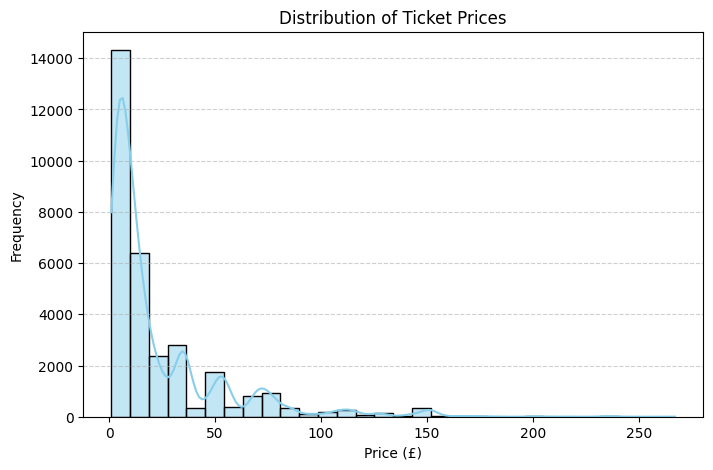

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True, bins=30, color="skyblue")
plt.title("Distribution of Ticket Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

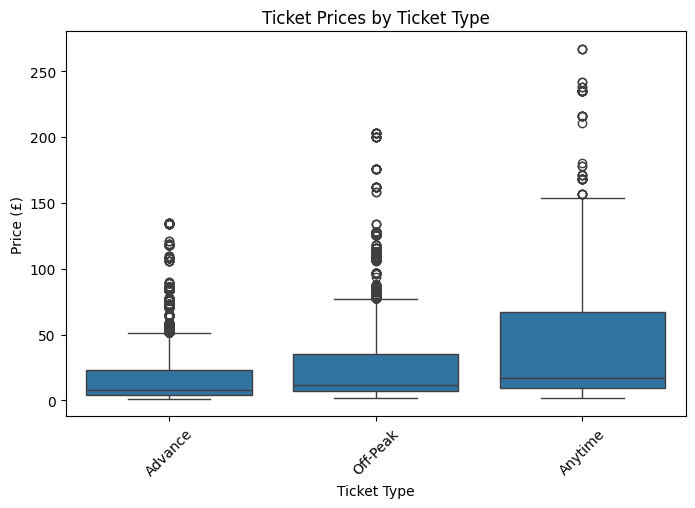

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="ticket_type", y="price")
plt.title("Ticket Prices by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Price (£)")
plt.xticks(rotation=45)
plt.show()

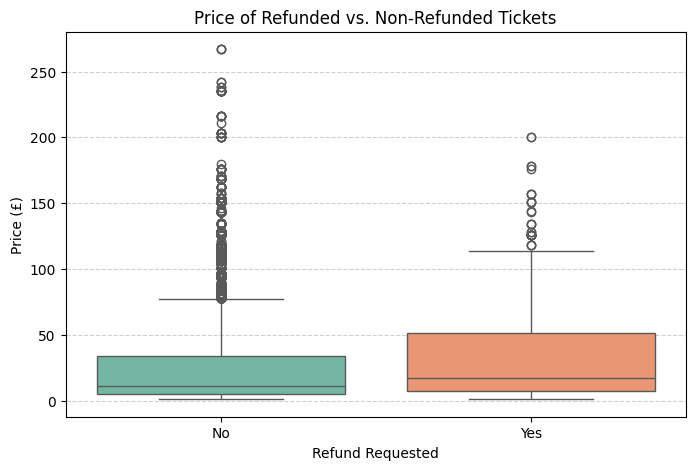

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="refund_request", y="price", hue="refund_request", palette="Set2", legend=False)
plt.title("Price of Refunded vs. Non-Refunded Tickets")
plt.xlabel("Refund Requested")
plt.ylabel("Price (£)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Refund requests happen more often for mid-to-high priced tickets, but not always for the highest.
Price alone doesn't explain refund behavior, other factors like delay and cancel reasons, and journey status look to be stronger predictors

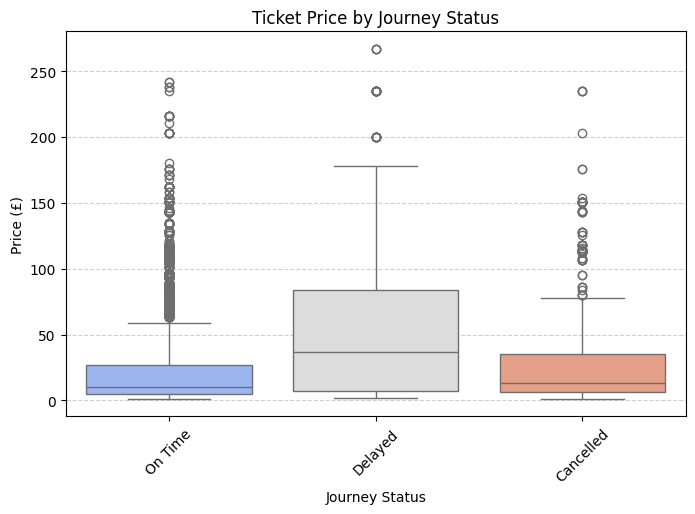

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="journey_status", y="price", hue="journey_status", palette="coolwarm", legend=False)
plt.title("Ticket Price by Journey Status")
plt.xlabel("Journey Status")
plt.ylabel("Price (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [21]:
df.head(3)

,date_of_purchase,time_of_purchase,purchase_type,payment_method,railcard,ticket_class,ticket_type,price,departure_station,arrival_destination,...,estimated_time_of_arrival,actual_arrival_time,journey_status,reason_for_delay,refund_request,day_of_purchase,day_of_journey,trip_minutes,delay_minutes,route
0,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,...,13:30:00,13:30:00,On Time,Not Eligible,No,Friday,Monday,150.0,0.0,London Paddington to Liverpool Lime Street
1,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,...,11:35:00,11:40:00,Delayed,Signal Failure,No,Saturday,Monday,110.0,5.0,London Kings Cross to York
2,2023-12-19,19:51:27,Online,Credit Card,None,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,...,18:45:00,18:45:00,On Time,Not Eligible,No,Tuesday,Tuesday,30.0,0.0,Liverpool Lime Street to Manchester Piccadilly


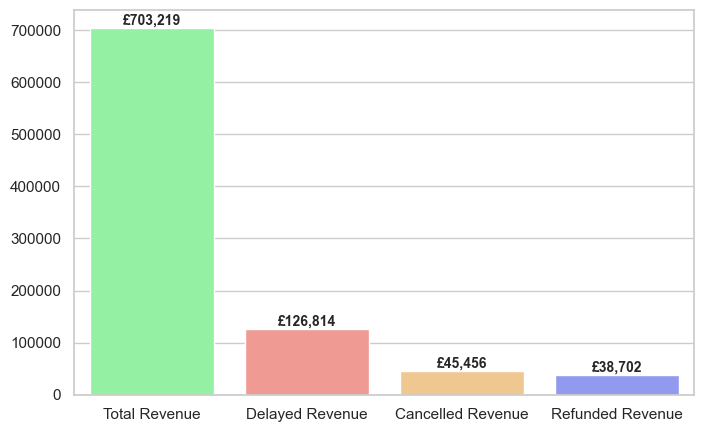

In [ ]:
sns.set(style="whitegrid")

cancelled_revenue = df[df["journey_status"].str.lower() == "cancelled"]["price"].sum()

delayed_revenue = df[df["journey_status"].str.lower() == "delayed"]["price"].sum()

refunded_revenue = df[df["refund_request"] == "Yes"]["price"].sum()

total_revenue = df["price"].sum() - refunded_revenue

revenue_labels = ["Total Revenue", "Delayed Revenue", "Cancelled Revenue", "Refunded Revenue" ]
revenue_values = [total_revenue, df[df["journey_status"].str.lower() == "delayed"]["price"].sum(), cancelled_revenue, refunded_revenue]
colors = ["#85FF97", "#FF8D85", "#FFCA81","#818DFF"] 

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_labels, y=revenue_values, hue = revenue_labels, palette=colors, legend=False )

for i, value in enumerate(revenue_values):
    plt.text(i, value + 500, f"£{value:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

In [23]:
df.head(3)

,date_of_purchase,time_of_purchase,purchase_type,payment_method,railcard,ticket_class,ticket_type,price,departure_station,arrival_destination,...,estimated_time_of_arrival,actual_arrival_time,journey_status,reason_for_delay,refund_request,day_of_purchase,day_of_journey,trip_minutes,delay_minutes,route
0,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,...,13:30:00,13:30:00,On Time,Not Eligible,No,Friday,Monday,150.0,0.0,London Paddington to Liverpool Lime Street
1,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,...,11:35:00,11:40:00,Delayed,Signal Failure,No,Saturday,Monday,110.0,5.0,London Kings Cross to York
2,2023-12-19,19:51:27,Online,Credit Card,None,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,...,18:45:00,18:45:00,On Time,Not Eligible,No,Tuesday,Tuesday,30.0,0.0,Liverpool Lime Street to Manchester Piccadilly


## Trip Cancel and Delay Analysis

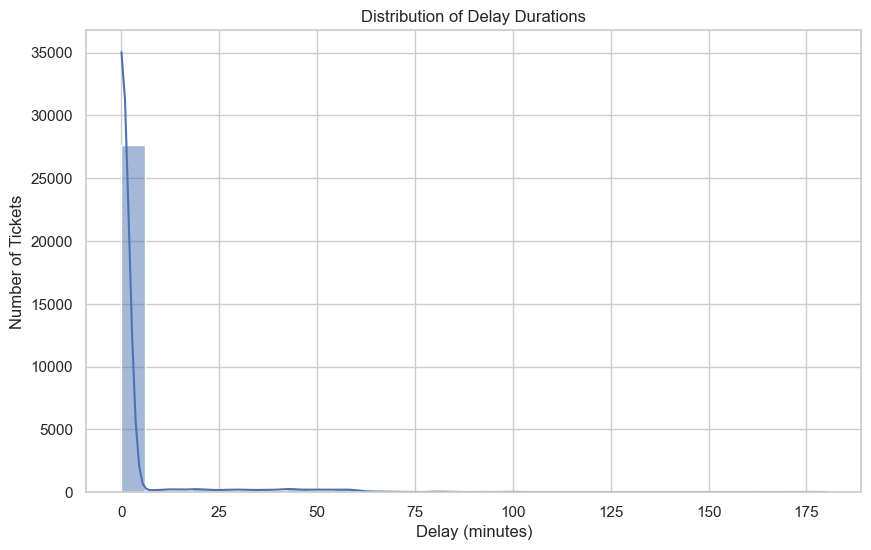

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df["delay_minutes"], bins=30, kde=True)
plt.title("Distribution of Delay Durations")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Tickets")
plt.show()

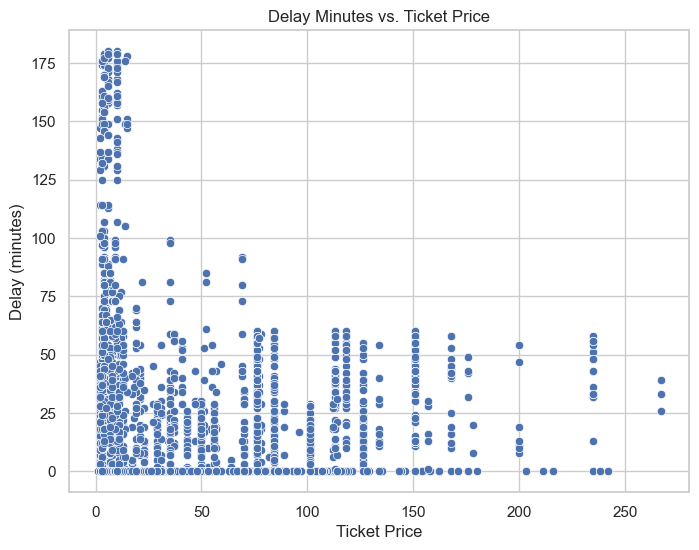

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="price", y="delay_minutes")
plt.title("Delay Minutes vs. Ticket Price")
plt.xlabel("Ticket Price")
plt.ylabel("Delay (minutes)")
plt.show()

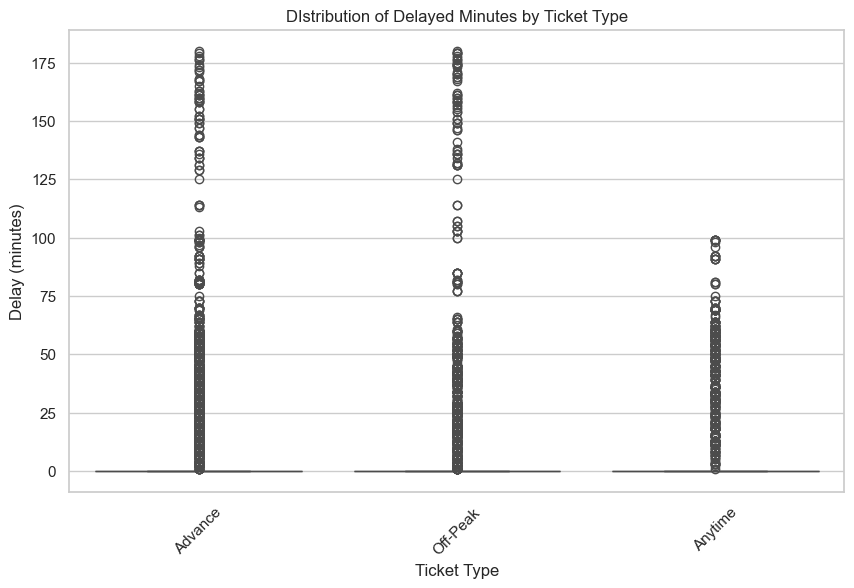

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="ticket_type", y="delay_minutes")
plt.title("DIstribution of Delayed Minutes by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\1382568358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette="Reds")


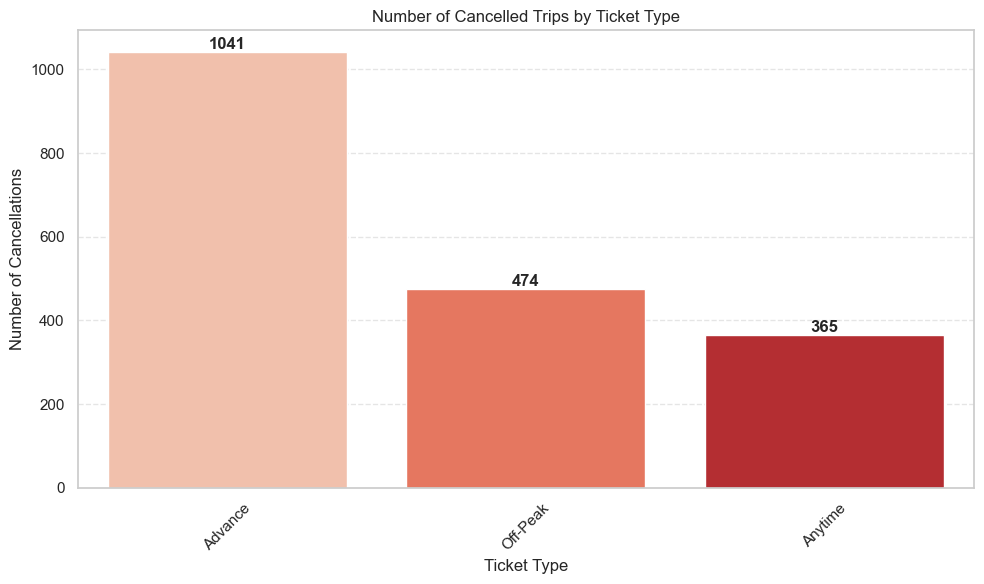

In [28]:
df["is_cancelled"] = df["journey_status"].str.lower().str.contains("cancelled")

cancel_counts = df[df["is_cancelled"]].groupby("ticket_type").size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette="Reds")

for i, value in enumerate(cancel_counts.values):
    plt.text(i, value + 1, f"{value}", ha="center", va="bottom", fontweight="bold")

plt.title("Number of Cancelled Trips by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\3642844989.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=delay_counts.index, y=delay_counts.values, palette="Oranges")  # hue removed


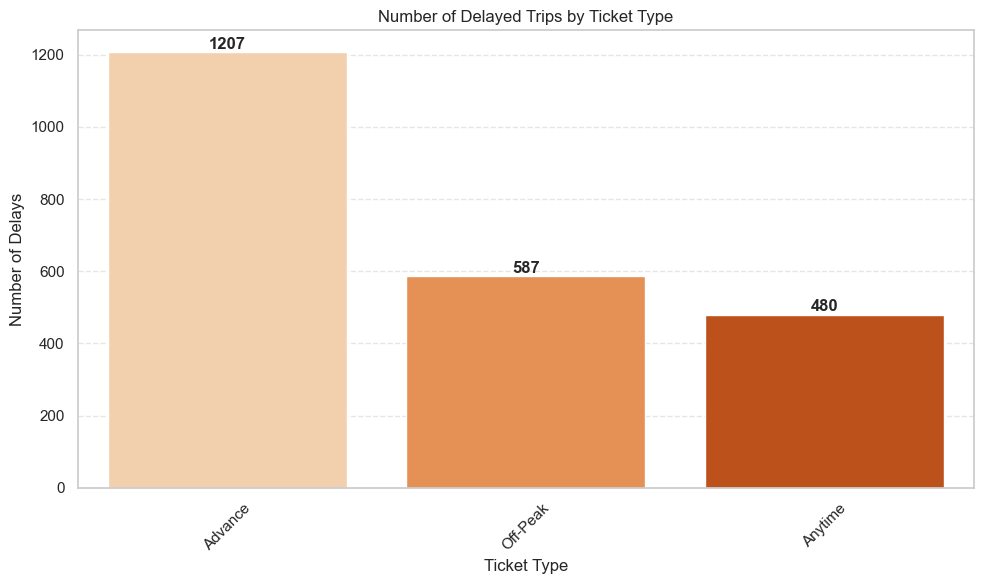

In [30]:
df["is_delayed"] = df["delay_minutes"] > 0

delay_counts = df[df["is_delayed"]].groupby("ticket_type").size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=delay_counts.index, y=delay_counts.values, palette="Oranges")  # hue removed

for i, value in enumerate(delay_counts.values):
    plt.text(i, value + 1, f"{value}", ha="center", va="bottom", fontweight="bold")

plt.title("Number of Delayed Trips by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Delays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


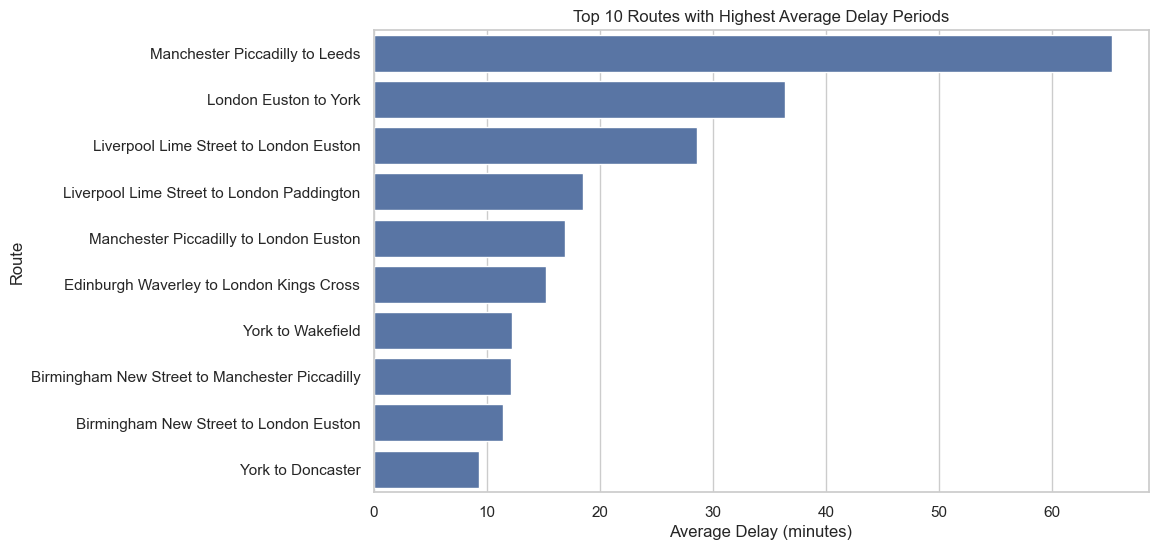

In [31]:
avg_delay_by_route = df.groupby("route")["delay_minutes"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_delay_by_route.values, y=avg_delay_by_route.index)
plt.title("Top 10 Routes with Highest Average Delay Periods")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Route")
plt.show()

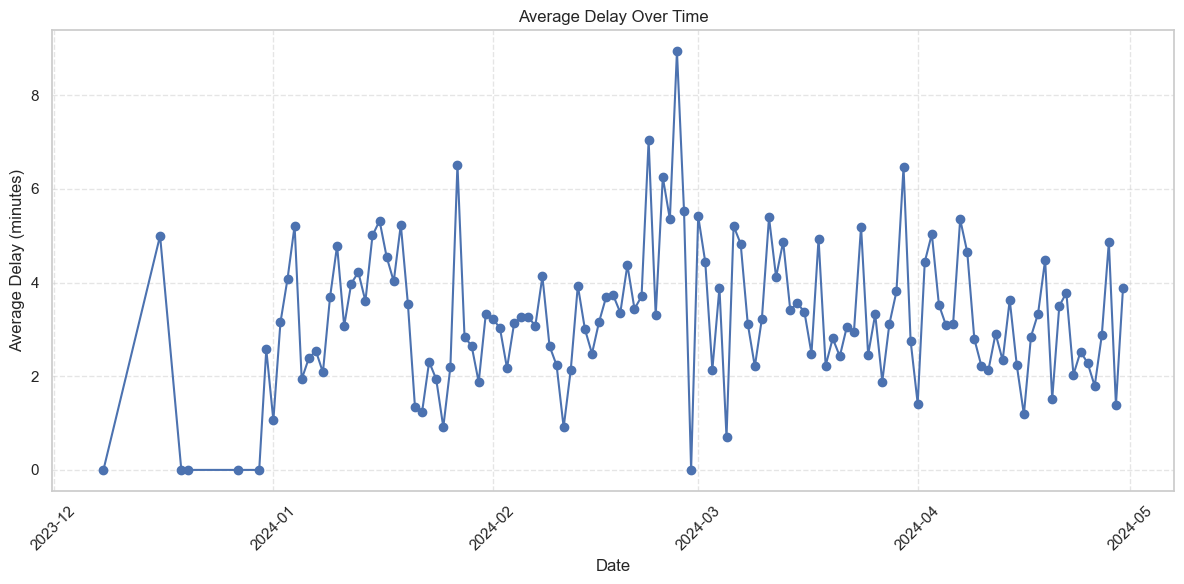

In [ ]:

df["date_of_purchase"] = pd.to_datetime(df["date_of_purchase"], errors="coerce")

df["date"] = df["date_of_purchase"].dt.date

delay_by_date = df.groupby("date")["delay_minutes"].mean()

plt.figure(figsize=(12, 6))
delay_by_date.plot(marker='o', linestyle='-')
plt.title("Average Delay Over Time")
plt.xlabel("Date")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


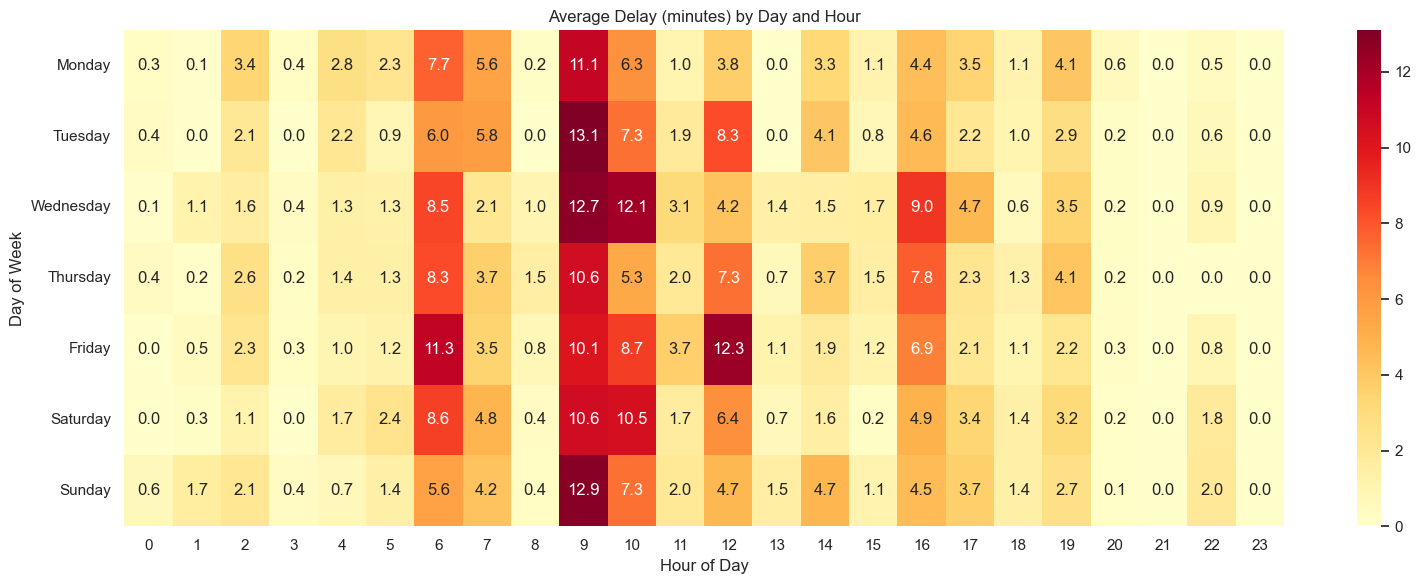

In [ ]:
df["date_of_purchase"] = pd.to_datetime(df["date_of_purchase"], errors="coerce")
df["time_of_purchase"] = pd.to_datetime(df["time_of_purchase"], format="%H:%M:%S", errors="coerce").dt.time

df["purchase_hour"] = df["time_of_purchase"].apply(lambda x: x.hour if pd.notnull(x) else None)

df["purchase_dayofweek"] = df["date_of_purchase"].dt.day_name()

delay_heatmap = df.pivot_table(
    index="purchase_dayofweek",
    columns="purchase_hour",
    values="delay_minutes",
    aggfunc="mean"
).reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

plt.figure(figsize=(16, 6))
sns.heatmap(delay_heatmap, cmap="YlOrRd", annot=True, fmt=".1f")
plt.title("Average Delay (minutes) by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

## Refund Behavior Analysis

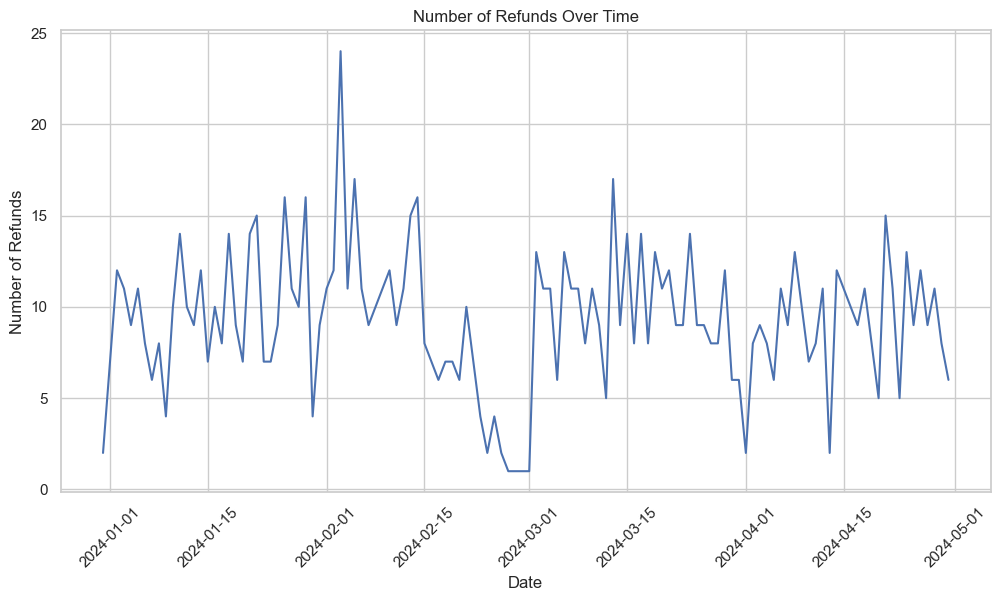

In [60]:
refund_trend = df[df["refund_request"] == "Yes"].groupby("date").size()

plt.figure(figsize=(12, 6))
refund_trend.plot()
plt.title("Number of Refunds Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Refunds")
plt.xticks(rotation=45)
plt.show()

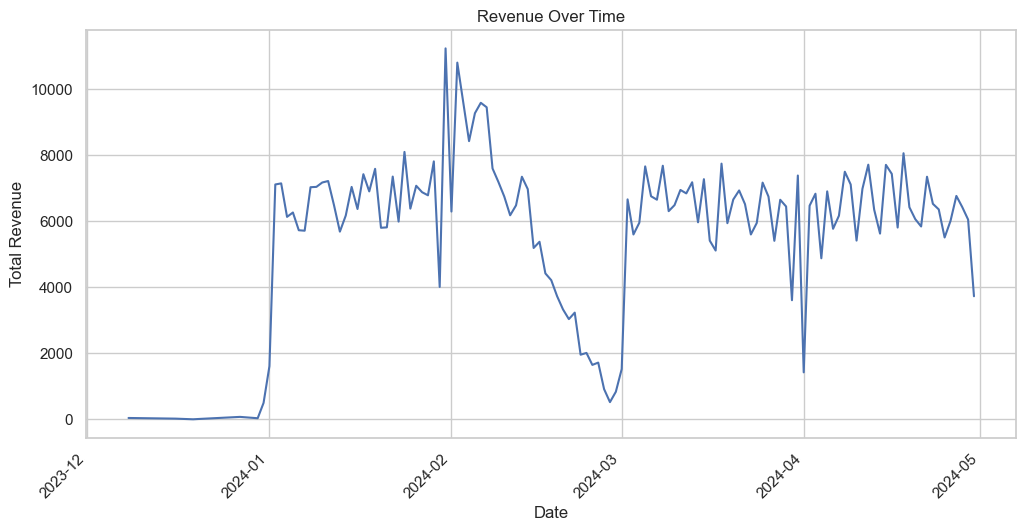

In [61]:
revenue_by_date = df.groupby("date_of_purchase")["price"].sum()

plt.figure(figsize=(12, 6))
revenue_by_date.plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

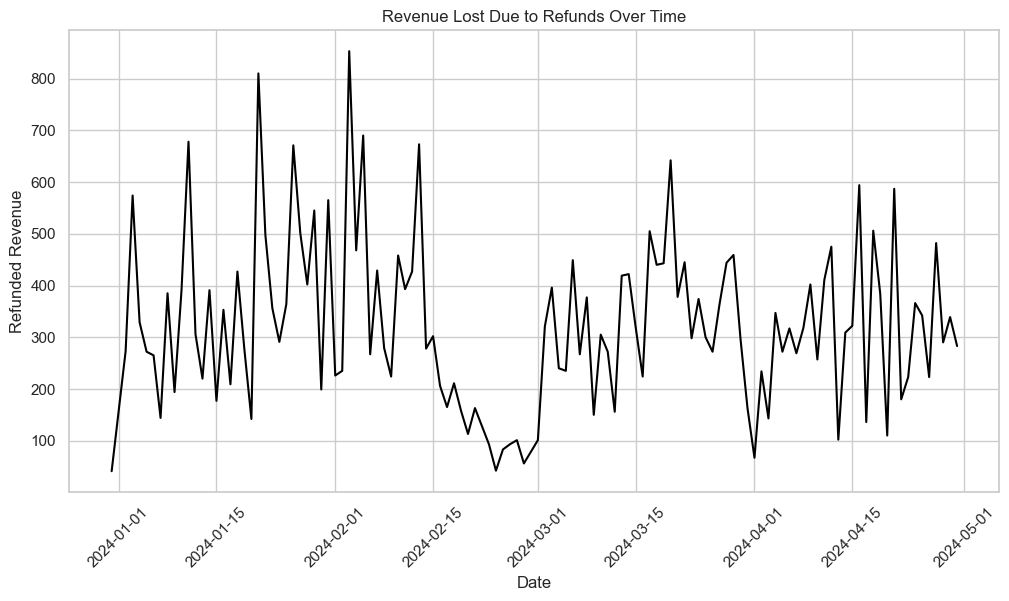

In [62]:
refund_loss = df[df["refund_request"] == "Yes"].groupby("date")["price"].sum()

plt.figure(figsize=(12, 6))
refund_loss.plot(color="black")
plt.title("Revenue Lost Due to Refunds Over Time")
plt.xlabel("Date")
plt.ylabel("Refunded Revenue")
plt.xticks(rotation=45)
plt.show()

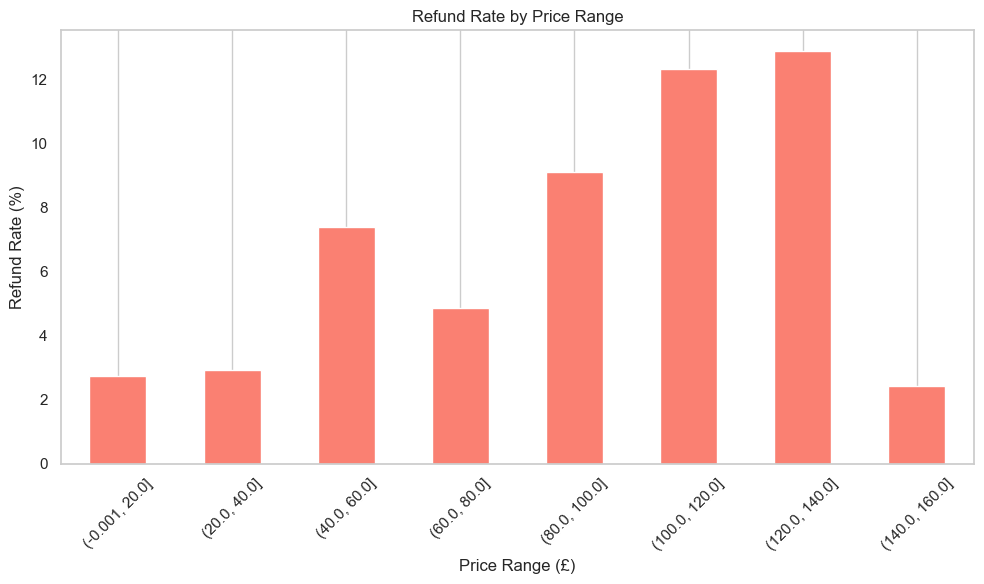

In [63]:
df["price_bin"] = pd.cut(df["price"], bins=[0, 20, 40, 60, 80, 100, 120, 140, 160], include_lowest=True)
refund_rate_by_price = pd.crosstab(df["price_bin"], df["refund_request"], normalize="index") * 100

refund_rate_by_price["Yes"].plot(kind="bar", figsize=(10,6), color="salmon")
plt.title("Refund Rate by Price Range")
plt.ylabel("Refund Rate (%)")
plt.xlabel("Price Range (£)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

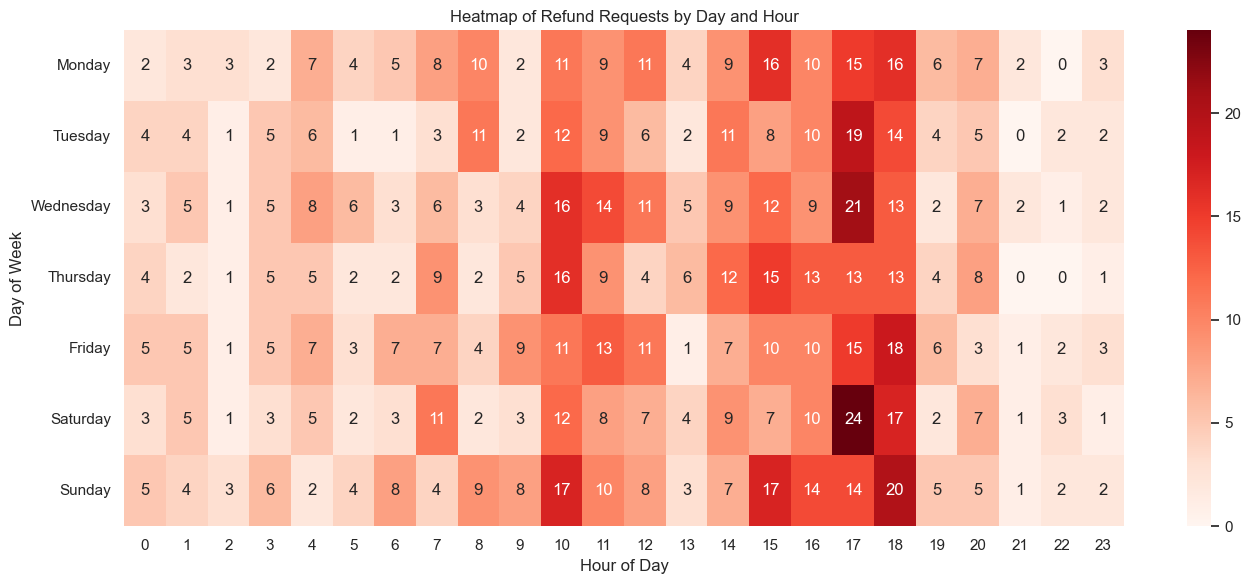

In [ ]:
df["date_of_purchase"] = pd.to_datetime(df["date_of_purchase"], errors="coerce")
df["time_of_purchase"] = pd.to_datetime(df["time_of_purchase"], format="%H:%M:%S", errors="coerce").dt.time

df["purchase_hour"] = df["time_of_purchase"].apply(lambda x: x.hour if pd.notnull(x) else None)
df["purchase_dayofweek"] = df["date_of_purchase"].dt.day_name()

df["is_refunded"] = df["refund_request"].str.lower() == "yes"

refunds = df[df["is_refunded"]]

refund_heatmap = refunds.groupby(["purchase_dayofweek", "purchase_hour"]).size().unstack(fill_value=0)

ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
refund_heatmap = refund_heatmap.reindex(ordered_days)

plt.figure(figsize=(14, 6))
sns.heatmap(refund_heatmap, cmap="Reds", annot=True, fmt="d")
plt.title("Heatmap of Refund Requests by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\2761531793.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


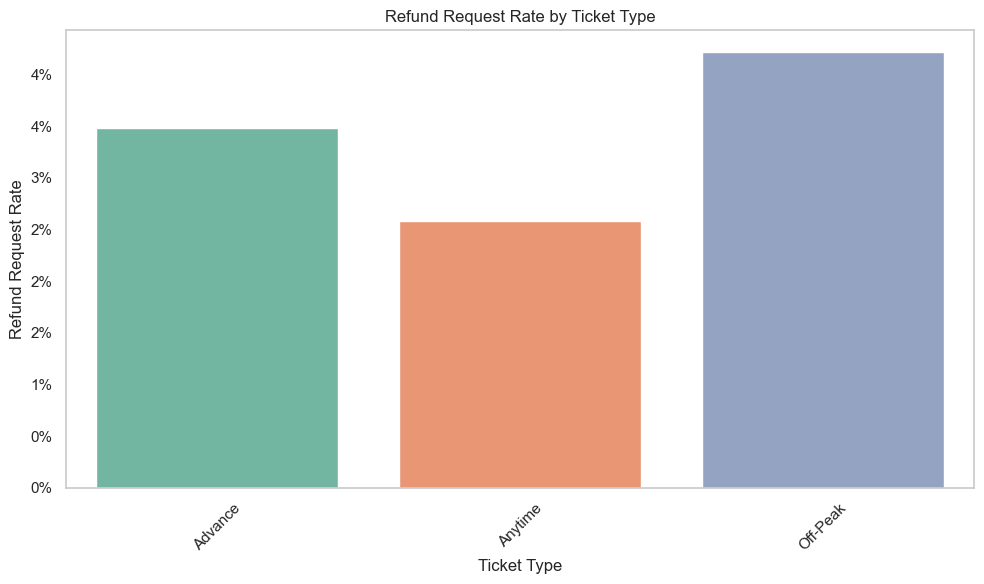

In [ ]:
refund_rate_by_type = df.groupby("ticket_type")["is_refunded"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=refund_rate_by_type,
    x="ticket_type",
    y="is_refunded",
    palette="Set2"
)
plt.title("Refund Request Rate by Ticket Type")
plt.ylabel("Refund Request Rate")
plt.xlabel("Ticket Type")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

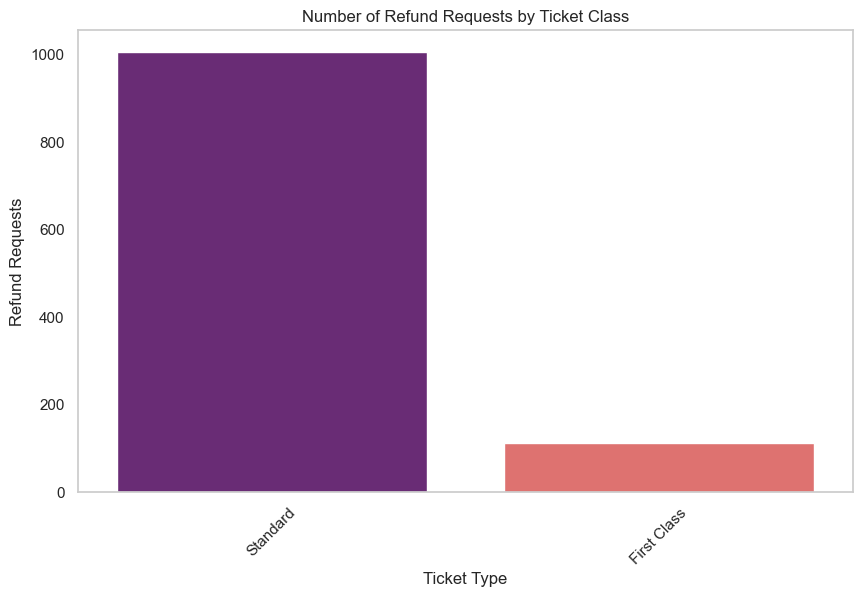

In [ ]:
refunds_only = df[df["refund_request"] == "Yes"]

refund_rates = refunds_only.groupby("ticket_class").size().reset_index(name="refund_count")

refund_rates = refund_rates.sort_values(by="refund_count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=refund_rates, x="ticket_class", y="refund_count", hue="ticket_class", palette="magma", legend=False)
plt.title("Number of Refund Requests by Ticket Class")
plt.xlabel("Ticket Type")
plt.ylabel("Refund Requests")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\1220862902.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


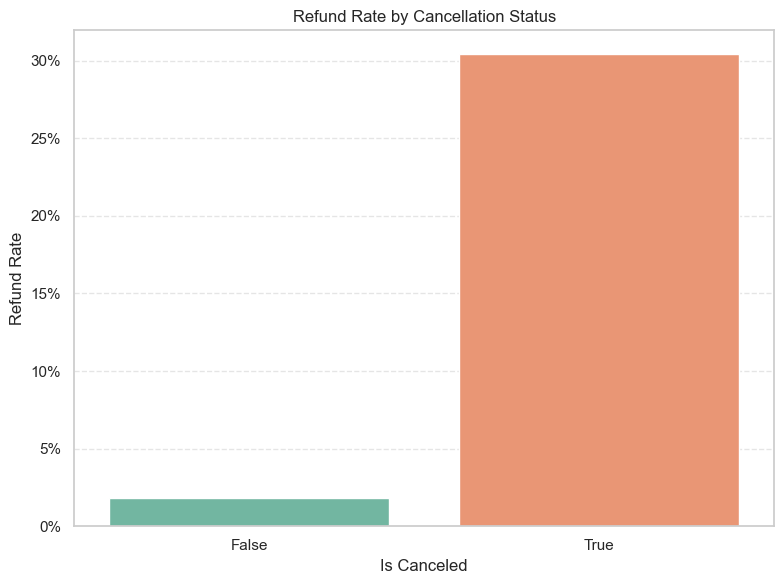

In [ ]:
df["is_canceled"] = df["journey_status"].str.lower() == "cancelled"

refund_by_cancel = df.groupby("is_canceled")["is_refunded"].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(
    data=refund_by_cancel,
    x="is_canceled",
    y="is_refunded",
    palette="Set2"
)
plt.title("Refund Rate by Cancellation Status")
plt.xlabel("Is Canceled")
plt.ylabel("Refund Rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df["refund_request_binary"] = df["refund_request"].apply(lambda x: 1 if x == "Yes" else 0)

delayed_trips = df[df["delay_minutes"] > 0]
refund_rate_delayed = delayed_trips["refund_request_binary"].mean()

cancelled_trips = df[df["journey_status"] == "Cancelled"]
refund_rate_cancelled = cancelled_trips["refund_request_binary"].mean()

print(f"Refund request rate for delayed trips: {refund_rate_delayed:.2%}")
print(f"Refund request rate for cancelled trips: {refund_rate_cancelled:.2%}")

Refund request rate for delayed trips: 23.66%
Refund request rate for cancelled trips: 30.43%


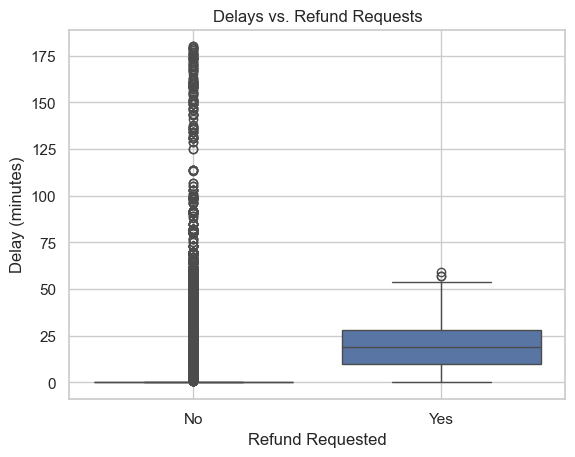

In [ ]:
sns.boxplot(data=df, x="refund_request", y="delay_minutes")
plt.title("Delays vs. Refund Requests")
plt.xlabel("Refund Requested")
plt.ylabel("Delay (minutes)")
plt.grid(True)
plt.show()

C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\3637270983.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


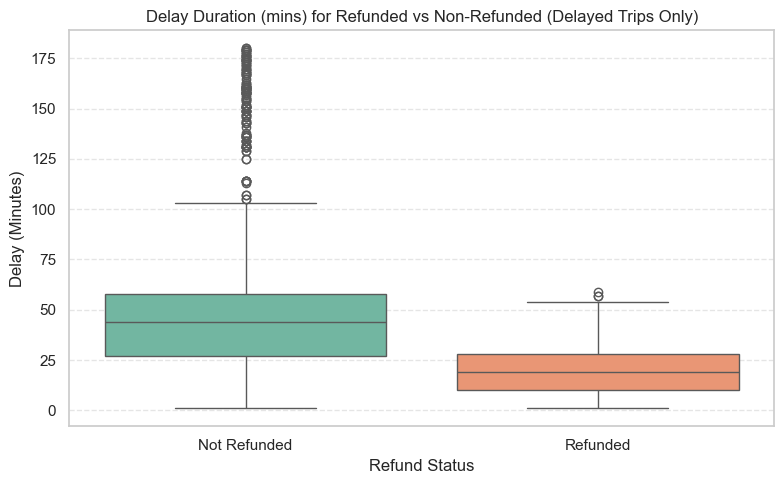

In [ ]:
df_delay_only = df[df["delay_minutes"] > 0].copy()

df_delay_only["refund_label"] = df_delay_only["is_refunded"].map({True: "Refunded", False: "Not Refunded"})

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_delay_only,
    x="refund_label",
    y="delay_minutes",
    palette="Set2"
)
plt.title("Delay Duration (mins) for Refunded vs Non-Refunded (Delayed Trips Only)")
plt.xlabel("Refund Status")
plt.ylabel("Delay (Minutes)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
table = pd.crosstab(df["is_canceled"], df["refund_request_binary"])
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi2: {chi2:.2f}, p-value: {p:.4f}")
if p < 0.05:
    print("Statistically significant relationship between cancellation and refund request.")
else:
    print("No significant link between cancellation and refund.")

Chi2: 4234.23, p-value: 0.0000
Statistically significant relationship between cancellation and refund request.


In [ ]:
group_refund = df[df["refund_request_binary"] == 1]["delay_minutes"].dropna()
group_no_refund = df[df["refund_request_binary"] == 0]["delay_minutes"].dropna()

t_stat, p_value = ttest_ind(group_refund, group_no_refund, equal_var=False)

print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference in delays for refunded vs. non-refunded tickets.")
else:
    print("No significant difference in delays.")

T-statistic: 31.19, p-value: 0.0000
Significant difference in delays for refunded vs. non-refunded tickets.


In [ ]:
df_delay_only = df[df["delay_minutes"] > 0].copy()

df_delay_only = df_delay_only.dropna(subset=["delay_minutes", "refund_request_binary"])

group_refund = df_delay_only[df_delay_only["refund_request_binary"] == 1]["delay_minutes"]
group_no_refund = df_delay_only[df_delay_only["refund_request_binary"] == 0]["delay_minutes"]

t_stat, p_value = ttest_ind(group_refund, group_no_refund, equal_var=False)

print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference in delays for refunded vs. non-refunded tickets (with delay only).")
else:
    print("No significant difference in delays.")

T-statistic: -28.61, p-value: 0.0000
Significant difference in delays for refunded vs. non-refunded tickets (with delay only).


I used a statistical test to see if the average delay time was significantly different between customers who requested for a refund and customers who didn’t request for a refund. This insight would greatly help prioritize refund policies and customer communication strategies for delays considering the delay time treshold

This There is a clear and significant difference in delay times between refunded and non-refunded tickets.
Customers who requested refunds experienced much longer delays

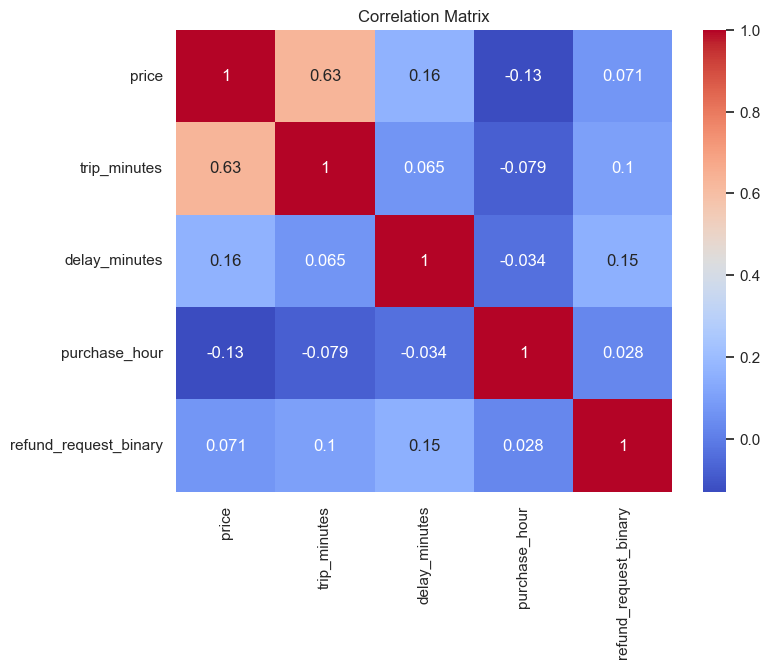

In [ ]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\1482113872.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


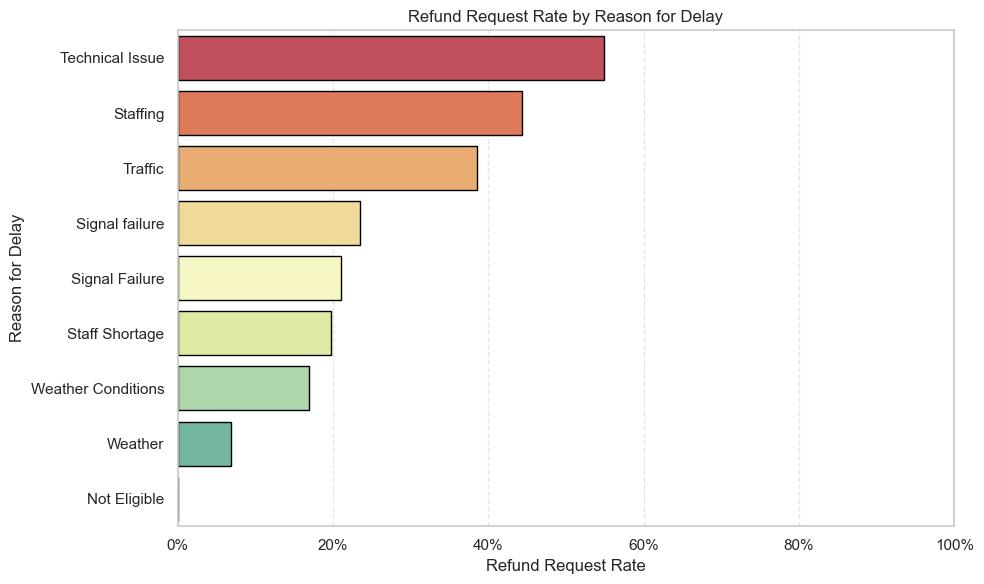

In [ ]:
df["is_delayed"] = df["delay_minutes"] > 0
df["is_cancelled"] = df["journey_status"].str.lower() == "cancelled"

refund_by_reason = (
    df[df["reason_for_delay"].notna()]
    .groupby("reason_for_delay")["is_refunded"]
    .mean()
    .reset_index()
    .sort_values(by="is_refunded", ascending=False)
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=refund_by_reason,
    y="reason_for_delay",
    x="is_refunded",
    palette="Spectral",
    edgecolor="black"
)
plt.xlabel("Refund Request Rate")
plt.ylabel("Reason for Delay")
plt.title("Refund Request Rate by Reason for Delay")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(df["reason_for_delay"], df["refund_request_binary"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2 Statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Statistically significant relationship between reason for delay and refund requests.")
else:
    print("No significant relationship between reason for delay and refund requests.")

Chi2 Statistic: 11151.19
p-value: 0.0000
Statistically significant relationship between reason for delay and refund requests.


C:\Users\MICHAEL KODUA BOAMAH\AppData\Local\Temp\ipykernel_15680\1554683494.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


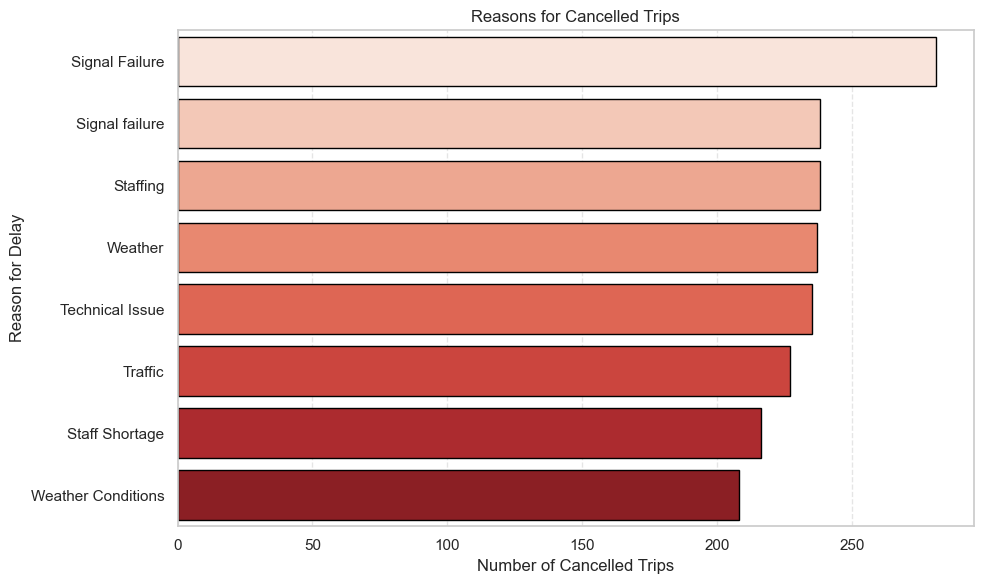

In [ ]:
df["is_cancelled"] = df["journey_status"] == "Cancelled"

cancelled_reasons = (
    df[df["is_cancelled"] & df["reason_for_delay"].notna()]
    .groupby("reason_for_delay")
    .size()
    .reset_index(name="cancelled_count")
    .sort_values(by="cancelled_count", ascending=False)
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cancelled_reasons,
    y="reason_for_delay",
    x="cancelled_count",
    palette="Reds",
    edgecolor="black"
)
plt.xlabel("Number of Cancelled Trips")
plt.ylabel("Reason for Delay")
plt.title("Reasons for Cancelled Trips")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chisquare

cancelled_only = df[df["is_cancelled"]].copy()
cancelled_only = cancelled_only[cancelled_only["reason_for_delay"].notna()]
observed = cancelled_only["reason_for_delay"].value_counts().sort_index()

expected = [observed.sum() / len(observed)] * len(observed)

chi2, p = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi2 Statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Statistically significant: some delay reasons are more common in cancellations.")
else:
    print("No significant difference: delay reasons are evenly distributed among cancellations.")

Chi2 Statistic: 14.01
p-value: 0.0510
No significant difference: delay reasons are evenly distributed among cancellations.


Analysis would be continued with Power BI and presented with Power BI

In [ ]:
df.to_csv("UK_railway_dataset_processed.csv", index=False)